In [2]:
import pandas as pd
import os
import glob
from collections import defaultdict

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from sklearn.metrics.pairwise import cosine_distances

def client_self_cosine_drift(data_latent):
    features = [col for col in data_latent.columns if col.startswith('x_')]
    results = []

    for client_id, group in data_latent.groupby('client_id'):
        group_sorted = group.sort_values('label')  # Ensure chronological order
        vectors = group_sorted[features].values
        labels = group_sorted['label'].values

        if len(vectors) < 2:
            continue  # Skip clients with only one label

        # First and last vectors
        first_vector = vectors[0].reshape(1, -1)
        last_vector = vectors[-1].reshape(1, -1)

        # # 1. Distance of last label to all previous labels
        # for i in range(len(vectors) - 1):
        #     res = {
        #         'client_id': client_id,
        #         'label': labels[i],
        #         'compared_to': labels[-1],
        #         'drift_type': 'last_vs_earlier',
        #         'cosine_distance': cosine_distances(vectors[i].reshape(1, -1), last_vector)[0][0],
        #     }
        #     results.append(res)

        # 2. Distance of first label to all later labels
        for i in range(1, len(vectors)):
            res = {
                'client_id': client_id,
                'label': labels[i],
                'compared_to': labels[0],
                'drift_type': 'first_vs_later',
                'cosine_distance': cosine_distances(vectors[i].reshape(1, -1), first_vector)[0][0],
            }
            results.append(res)

        # 3. Rolling (Consecutive)
        for i in range(len(vectors) - 1):
            results.append({
                'client_id': client_id,
                'label': labels[i],
                'compared_to': labels[i + 1],
                'drift_type': 'rolling',
                'cosine_distance': cosine_distances(vectors[i].reshape(1, -1), vectors[i + 1].reshape(1, -1))[0][0],
            })

    return pd.DataFrame(results)

def plot_cosine_drift(df_drift):
    # Filter labels <11 or >13
    df_plot = df_drift[(df_drift['label'] < 11) | (df_drift['label'] > 12)].copy()

    # Create new column for FacetGrid row
    df_plot['label_range'] = df_plot['label'].apply(lambda x: '<11' if x < 11 else '>13')

    # Plot using seaborn FacetGrid
    g = sns.FacetGrid(
        df_plot,
        row='label_range',
        col='drift_type',
        hue='client_id',
        margin_titles=True,
        sharey=False,
        sharex=True,
        height=3,
        aspect=1
    )

    g.map_dataframe(sns.lineplot, x='label', y='cosine_distance')

    g.add_legend()
    g.set_axis_labels("Label", "Cosine Distance")
    g.set_titles(col_template="{col_name}", row_template="Label {row_name}")
    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle("Client Self-Cosine Drift Over Labels", fontsize=16)

    plt.show()

In [6]:
import random
from collections import defaultdict

import random
from collections import defaultdict

def balanced_sample_per_class(folder_experiment, n_per_class):
    # 1. Group entries by class (A_, B_, C_, D_, E_)
    class_groups = defaultdict(list)
    for item in folder_experiment:
        filename = item.split('\\')[-1]  # get just the file part
        prefix = filename[:2]  # expects A_, B_, etc.
        if prefix in ['A_', 'B_', 'C_', 'D_', 'E_']:
            class_groups[prefix].append(item)

    # 2. Sample n items per class (if enough data is available)
    result = []
    for cls, items in class_groups.items():
        if len(items) < n_per_class:
            raise ValueError(f"Not enough items in class {cls}: needed {n_per_class}, found {len(items)}")
        result.extend(random.sample(items, n_per_class))

    return result



folders_experiment = [f for f in glob.glob(os.path.join('results', '*EXPERIMENT_INCOMESIMPLE*')) if os.path.isdir(f)]

sampled = balanced_sample_per_class(folders_experiment, 2)
for s in sampled:
    print(s)

results\A_62_LL_ML__LL_HL_LL_LL_ML_10_1_2_24_EXPERIMENT_INCOMESIMPLE_LL_HL_LL_LL_ML__24_2_7200___0
results\A_62_LL_HL__LL_HL_LL_LL_ML_10_1_2_12_EXPERIMENT_INCOMESIMPLE_LL_HL_LL_LL_ML__12_2_7200___0
results\B_84_LL_ML__ML_LL_HL_LL_LL_10_1_1_12_EXPERIMENT_INCOMESIMPLE_ML_LL_HL_LL_LL__12_2_3600___0
results\B_84_LL_HL__HL_LL_ML_LL_LL_10_1_2_24_EXPERIMENT_INCOMESIMPLE_HL_LL_ML_LL_LL__24_2_7200___0
results\C_65_LL_ML__HL_ML_LL_LL_LL_10_1_1_12_EXPERIMENT_INCOMESIMPLE_HL_ML_LL_LL_LL__12_2_3600___0
results\C_65_LL_HL__ML_HL_LL_LL_LL_10_1_2_24_EXPERIMENT_INCOMESIMPLE_ML_HL_LL_LL_LL__24_2_7200___0
results\D_2_LL_ML__ML_HL_LL_LL_LL_10_1_2_12_EXPERIMENT_INCOMESIMPLE_ML_HL_LL_LL_LL__12_2_7200___0
results\D_2_LL_ML__HL_ML_LL_LL_LL_10_1_1_12_EXPERIMENT_INCOMESIMPLE_HL_ML_LL_LL_LL__12_2_3600___0
results\E_15_LL_ML__LL_HL_ML_LL_LL_10_1_2_12_EXPERIMENT_INCOMESIMPLE_LL_HL_ML_LL_LL__12_2_7200___0
results\E_15_LL_HL__ML_HL_LL_LL_LL_10_1_2_12_EXPERIMENT_INCOMESIMPLE_ML_HL_LL_LL_LL__12_2_7200___0




EXPERIMENT results\A_62_LL_ML__LL_HL_LL_LL_ML_10_1_2_24_EXPERIMENT_INCOMESIMPLE_LL_HL_LL_LL_ML__24_2_7200___0:


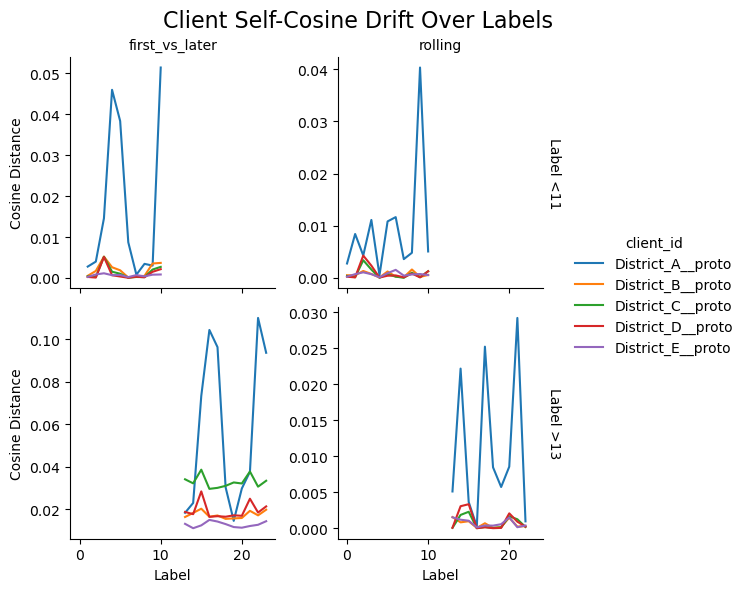



EXPERIMENT results\A_62_LL_HL__LL_HL_LL_LL_ML_10_1_2_12_EXPERIMENT_INCOMESIMPLE_LL_HL_LL_LL_ML__12_2_7200___0:


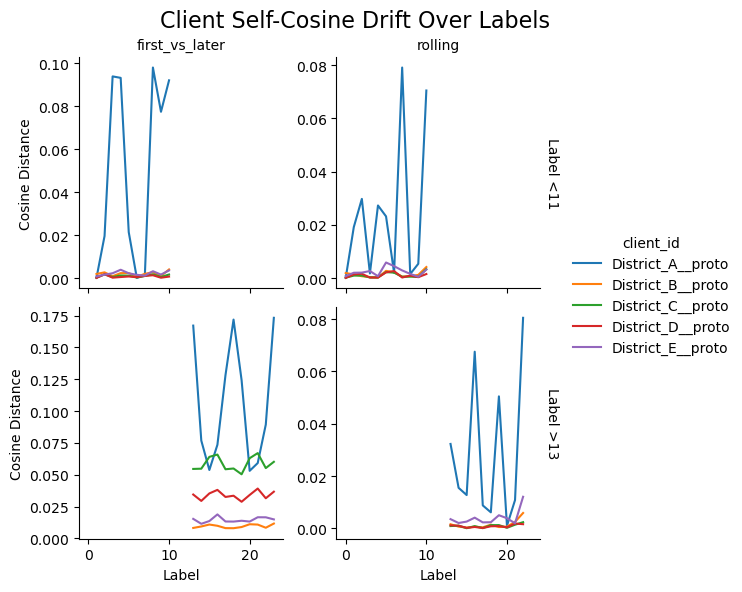



EXPERIMENT results\B_84_LL_ML__ML_LL_HL_LL_LL_10_1_1_12_EXPERIMENT_INCOMESIMPLE_ML_LL_HL_LL_LL__12_2_3600___0:


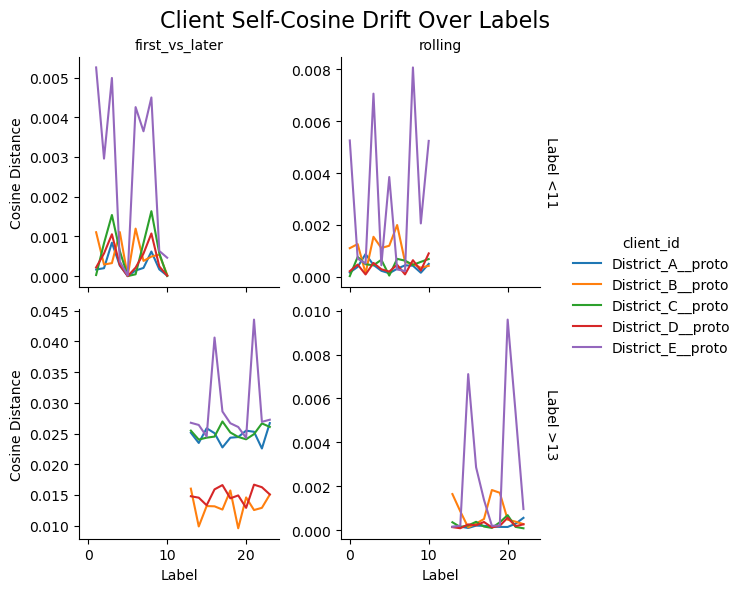



EXPERIMENT results\B_84_LL_HL__HL_LL_ML_LL_LL_10_1_2_24_EXPERIMENT_INCOMESIMPLE_HL_LL_ML_LL_LL__24_2_7200___0:


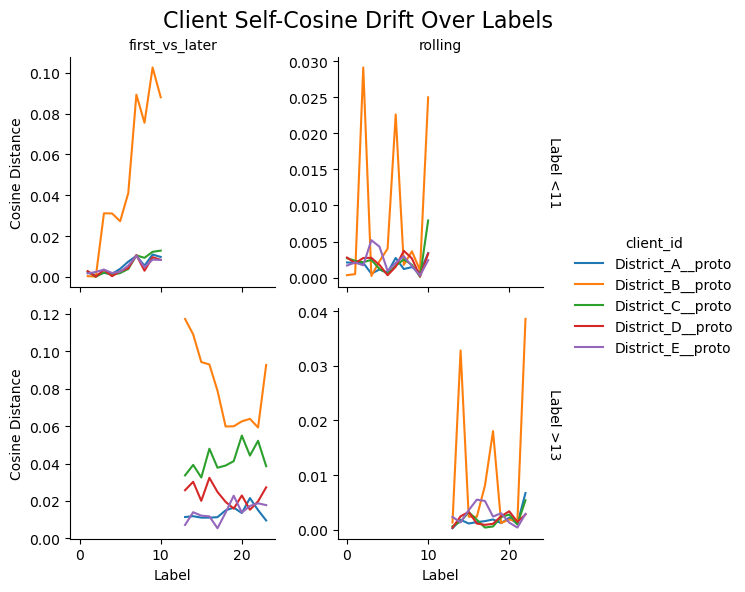



EXPERIMENT results\C_65_LL_ML__HL_ML_LL_LL_LL_10_1_1_12_EXPERIMENT_INCOMESIMPLE_HL_ML_LL_LL_LL__12_2_3600___0:


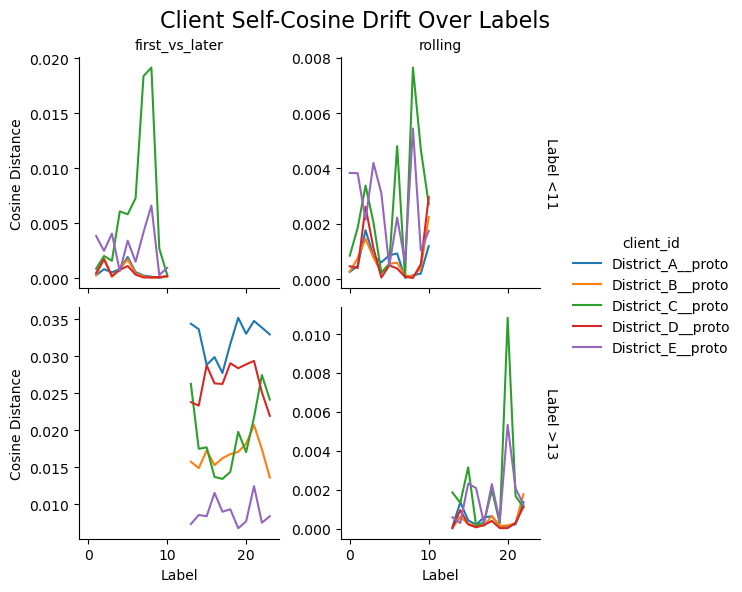



EXPERIMENT results\C_65_LL_HL__ML_HL_LL_LL_LL_10_1_2_24_EXPERIMENT_INCOMESIMPLE_ML_HL_LL_LL_LL__24_2_7200___0:


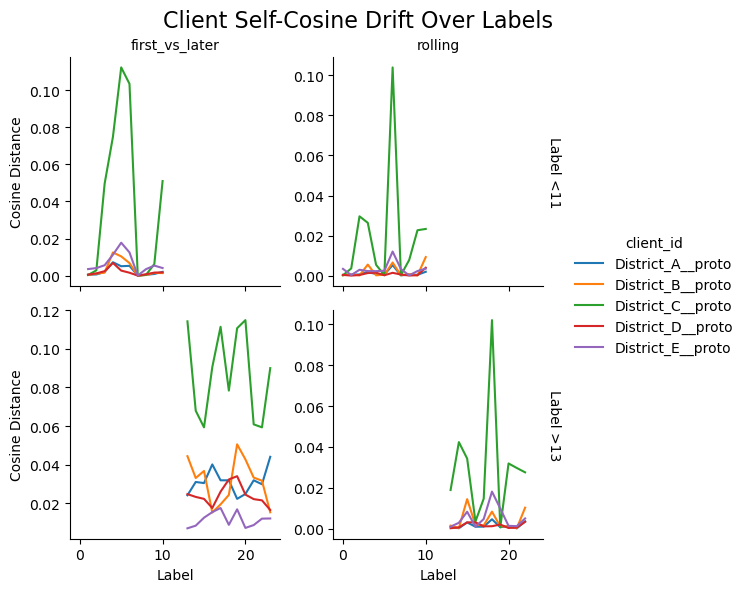



EXPERIMENT results\D_2_LL_ML__ML_HL_LL_LL_LL_10_1_2_12_EXPERIMENT_INCOMESIMPLE_ML_HL_LL_LL_LL__12_2_7200___0:


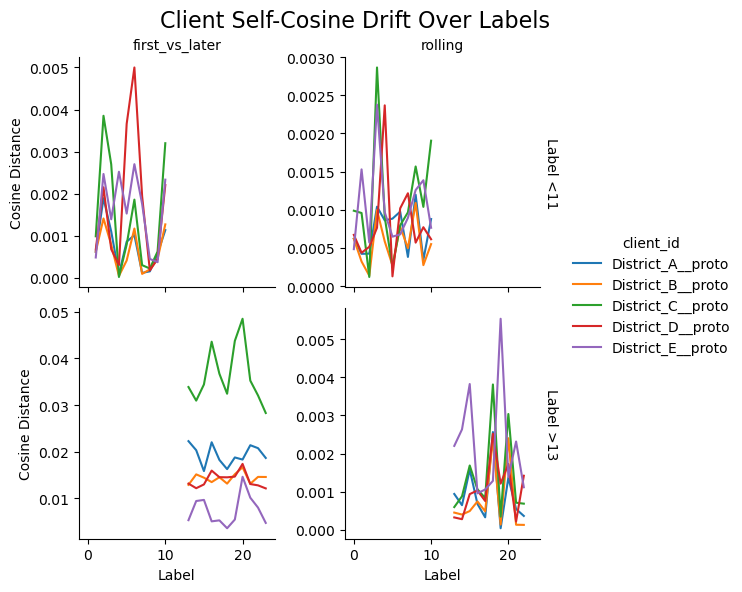



EXPERIMENT results\D_2_LL_ML__HL_ML_LL_LL_LL_10_1_1_12_EXPERIMENT_INCOMESIMPLE_HL_ML_LL_LL_LL__12_2_3600___0:


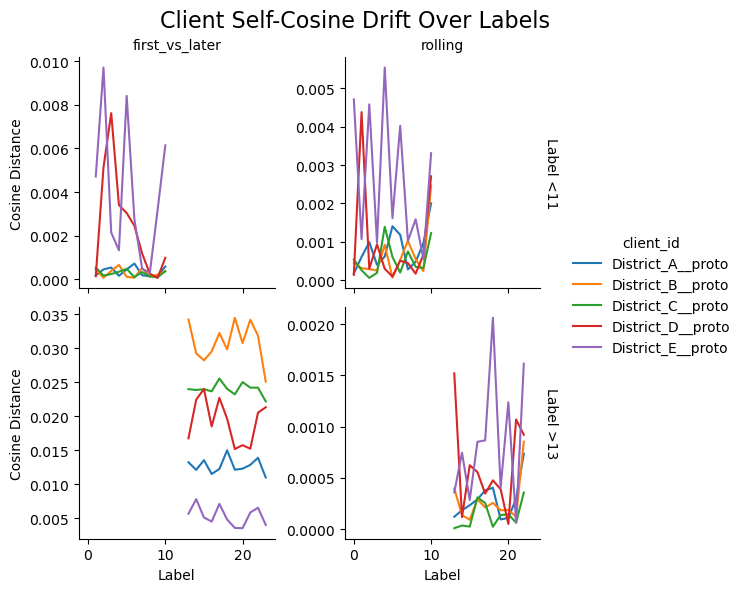



EXPERIMENT results\E_15_LL_ML__LL_HL_ML_LL_LL_10_1_2_12_EXPERIMENT_INCOMESIMPLE_LL_HL_ML_LL_LL__12_2_7200___0:


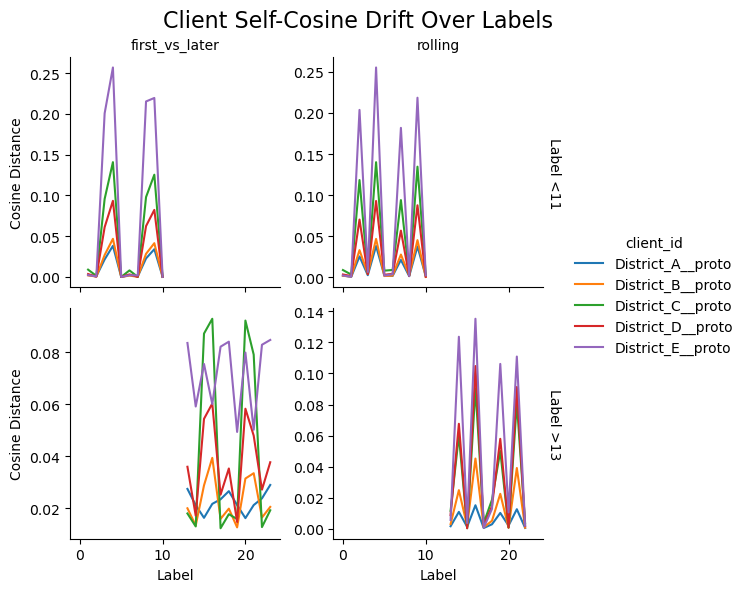



EXPERIMENT results\E_15_LL_HL__ML_HL_LL_LL_LL_10_1_2_12_EXPERIMENT_INCOMESIMPLE_ML_HL_LL_LL_LL__12_2_7200___0:


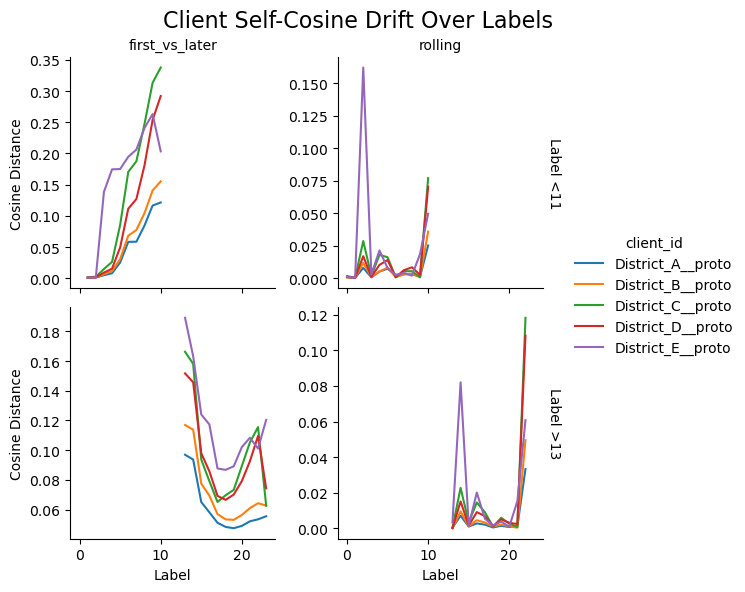

In [8]:
import warnings
warnings.filterwarnings('ignore')

for experiment in sampled:

    print(f'\n\nEXPERIMENT {experiment}:')

    data_path = experiment + '\Baseline_latent_space.parquet'
    new_latent = pd.read_parquet(data_path)
    data_epoch = new_latent[(new_latent['epoch'] == '9') & (new_latent['client_id'].str.contains('_proto'))]

    df_drift = client_self_cosine_drift(data_epoch)

    plot_cosine_drift(df_drift)

In [10]:
def rank_clients_by_drift(df):
    # 1. Filter out unwanted labels
    df = df[~df['label'].isin([11, 12])].copy()

    # 2. Define the periods
    periods = {
        'first_4_months': list(range(0, 4)),
        'first_year': list(range(0, 11)),
        'second_year': list(range(13, 23)),
        'all_periods': sorted(df['label'].unique())  # already excludes 11, 12
    }

    # 3. Store results in a dictionary
    ranked_results = {}

    for period_name, valid_labels in periods.items():
        df_period = df[df['label'].isin(valid_labels)].copy()

        # === a) Per-label RANKING ===
        df_period['rank'] = df_period.groupby(['drift_type', 'label'])['cosine_distance']\
                                     .rank(method='dense', ascending=False)

        # === b) Summary STATS (mean and sum per client) ===
        agg_stats = df_period.groupby(['drift_type', 'client_id'])['cosine_distance']\
                             .agg(['mean', 'sum'])\
                             .rename(columns={'mean': 'mean_distance', 'sum': 'sum_distance'})\
                             .reset_index()

        # === c) Rank clients by mean and sum ===
        agg_stats['rank_by_mean'] = agg_stats.groupby('drift_type')['mean_distance']\
                                             .rank(method='dense', ascending=False)

        agg_stats['rank_by_sum'] = agg_stats.groupby('drift_type')['sum_distance']\
                                            .rank(method='dense', ascending=False)

        # Store both the detailed and summary DataFrames
        ranked_results[period_name] = {
            'detailed': df_period,
            'summary': agg_stats
        }

    return ranked_results


In [12]:
from collections import defaultdict
import os

def analyze_experiments_by_epoch(data, epochs = None, top_n=2):
    results = {}

    for experiment in data:
        results[experiment] = {}

        data_path = os.path.join(experiment, 'Baseline_latent_space.parquet')
        new_latent = pd.read_parquet(data_path)

        experiment_summary_rows = []

        epochs_loop = epochs if epochs is not None else new_latent['epoch'].sort_values().unique()
        for epoch in epochs_loop:
            data_epoch = new_latent[
                (new_latent['epoch'].astype(str) == str(epoch)) &
                (new_latent['client_id'].str.contains('_proto'))
            ]

            if data_epoch.empty:
                print(f'    ⚠ No data for epoch {epoch}, skipping...')
                continue

            df_drift = client_self_cosine_drift(data_epoch)
            ranked = rank_clients_by_drift(df_drift)

            compiled_summaries = {}

            for period_name, result in ranked.items():
                summary = result['summary'].copy()

                summary['experiment'] = experiment
                summary['epoch'] = epoch
                summary['period'] = period_name

                # Rank delta
                summary['rank_diff'] = (summary['rank_by_mean'] - summary['rank_by_sum']).abs()

                # Collect for experiment-level summary
                experiment_summary_rows.append(summary)

                # Top-N for both rank types
                top_by_mean = summary.sort_values(['drift_type', 'rank_by_mean']).groupby('drift_type').head(top_n)
                top_by_mean['rank_type'] = 'mean'

                top_by_sum = summary.sort_values(['drift_type', 'rank_by_sum']).groupby('drift_type').head(top_n)
                top_by_sum['rank_type'] = 'sum'

                compiled = pd.concat([top_by_mean, top_by_sum], ignore_index=True)
                compiled.sort_values(by=['drift_type', 'rank_type'], inplace=True)

                compiled_summaries[period_name] = compiled

            results[experiment][epoch] = {
                'ranked': ranked,
                'compiled_summary': compiled_summaries
            }

        # 🔄 Per-Experiment Global Analysis
        if experiment_summary_rows:
            exp_df = pd.concat(experiment_summary_rows, ignore_index=True)

            # === 1. Average Ranks + Rank Delta ===
            avg_ranks = exp_df.groupby(['client_id', 'drift_type'])[
                ['rank_by_mean', 'rank_by_sum', 'rank_diff']
            ].mean().reset_index()
            avg_ranks.rename(columns={
                'rank_by_mean': 'avg_rank_by_mean',
                'rank_by_sum': 'avg_rank_by_sum',
                'rank_diff': 'avg_rank_delta'
            }, inplace=True)

            # === 2. Stability Index (Top-N appearances) ===
            stability_counts = defaultdict(lambda: {'mean': 0, 'sum': 0})
            for _, row in exp_df.iterrows():
                if row['rank_by_mean'] <= top_n:
                    stability_counts[(row['client_id'], row['drift_type'])]['mean'] += 1
                if row['rank_by_sum'] <= top_n:
                    stability_counts[(row['client_id'], row['drift_type'])]['sum'] += 1

            stability_df = pd.DataFrame([
                {
                    'client_id': cid,
                    'drift_type': drift_type,
                    'stability_topN_mean': counts['mean'],
                    'stability_topN_sum': counts['sum']
                }
                for (cid, drift_type), counts in stability_counts.items()
            ])

            # === 3. Combine metrics
            experiment_metrics = avg_ranks.merge(stability_df, on=['client_id', 'drift_type'], how='outer')
            results[experiment]['summary_metrics'] = experiment_metrics
            results[experiment]['all_summary_df'] = exp_df

        else:
            results[experiment]['summary_metrics'] = pd.DataFrame()
            results[experiment]['all_summary_df'] = pd.DataFrame()

    return results

results = analyze_experiments_by_epoch(data = folders_experiment, epochs = None)

import pickle

with open('results/imgs/experiment_income_simple_analysis.pkl', 'wb') as f:
    pickle.dump(results, f)

In [13]:
best_cases = []

for experiment, content in results.items():
    summary = content.get('summary_metrics')
    if summary is None or summary.empty:
        continue

    # Sort and get top 1 per drift_type
    top_clients = (
        summary.sort_values(['drift_type', 'avg_rank_by_mean'])
        .groupby('drift_type')
        .head(1)
        .copy()
    )

    # Add experiment name
    top_clients['experiment'] = experiment

    # Keep only required columns
    best_cases.append(top_clients[['client_id', 'drift_type', 'experiment']])

# Combine into a single DataFrame
best_cases_df = pd.concat(best_cases, ignore_index=True)
best_cases_df['client_drift'] = best_cases_df['client_id'].str.split('_').str[1]
best_cases_df['ground_truth'] = best_cases_df['experiment'].str.replace('results\\', '').str[0]
best_cases_df['check'] = best_cases_df['client_drift'] == best_cases_df['ground_truth']
best_cases_df.head()

,client_id,drift_type,experiment,client_drift,ground_truth,check
0,District_A__proto,first_vs_later,results\A_62_LL_HL__LL_HL_LL_LL_ML_10_1_2_12_E...,A,A,True
1,District_A__proto,rolling,results\A_62_LL_HL__LL_HL_LL_LL_ML_10_1_2_12_E...,A,A,True
2,District_A__proto,first_vs_later,results\A_62_LL_HL__LL_HL_LL_LL_ML_10_1_2_24_E...,A,A,True
3,District_A__proto,rolling,results\A_62_LL_HL__LL_HL_LL_LL_ML_10_1_2_24_E...,A,A,True
4,District_A__proto,first_vs_later,results\A_62_LL_HL__LL_HL_ML_LL_LL_10_1_2_12_E...,A,A,True


In [14]:
# income
ct = pd.crosstab(best_cases_df['drift_type'], best_cases_df['check'], normalize='index') * 100
ct = ct.round(2)
ct.rename(columns={True: 'correct_%', False: 'wrong_%'}, inplace=True)
ct

check,wrong_%,correct_%
drift_type,,
first_vs_later,21.14,78.86
rolling,19.43,80.57


In [15]:
best_cases_init_max = []

for experiment, content in results.items():
    aux_qwe = []
    for epoch in range(10):
        asd = content[str(epoch)]['ranked']['first_4_months']['detailed']
        asd = asd[asd['rank'] == 1]

        asd_max_cosine = asd.loc[asd.groupby('drift_type')['cosine_distance'].idxmax()].copy()
        asd_max_cosine['epoch'] = epoch
        aux_qwe.append(asd_max_cosine)

    df_qwe = pd.concat(aux_qwe)


    # Count how often each client_id appears at rank 1 for each drift_type
    pair_counts = (
        df_qwe.groupby(['drift_type', 'client_id'])
           .size()
           .reset_index(name='count')
    )

    # Find top clients per drift_type (those with max count)
    max_counts = pair_counts.groupby('drift_type')['count'].transform('max')
    top_clients_per_drift = pair_counts[pair_counts['count'] == max_counts].copy()

    # Add experiment info
    top_clients_per_drift['experiment'] = experiment

    # Append
    best_cases_init_max.append(top_clients_per_drift[['client_id', 'drift_type', 'experiment']])

# Combine all experiments
best_cases_init_max_df = pd.concat(best_cases_init_max, ignore_index=True)

# Add derived columns
best_cases_init_max_df['client_drift'] = best_cases_init_max_df['client_id'].str.split('_').str[1]
best_cases_init_max_df['ground_truth'] = best_cases_init_max_df['experiment'].str.replace('results\\', '', regex=False).str[0]
best_cases_init_max_df['check'] = best_cases_init_max_df['client_drift'] == best_cases_init_max_df['ground_truth']

# View results
ct = pd.crosstab(best_cases_init_max_df['drift_type'], best_cases_init_max_df['check'], normalize='index') * 100
ct = ct.round(2)
ct.rename(columns={True: 'correct_%', False: 'wrong_%'}, inplace=True)
ct

check,wrong_%,correct_%
drift_type,,
first_vs_later,26.14,73.86
rolling,27.37,72.63


In [49]:
best_cases_init_max_df[best_cases_init_max_df['check'] == False]

,client_id,drift_type,experiment,client_drift,ground_truth,check
17,District_E__proto,rolling,results\A_62_LL_ML__LL_ML_HL_LM_HM_10_1_1_12_E...,E,A,False
23,District_E__proto,rolling,results\A_62_LL_ML__LL_ML_HL_LM_HM_10_1_1_24_E...,E,A,False
34,District_A__proto,first_vs_later,results\B_84_LL_ML__HL_LL_ML_LH_LL_10_1_1_12_E...,A,B,False
35,District_A__proto,rolling,results\B_84_LL_ML__HL_LL_ML_LH_LL_10_1_1_12_E...,A,B,False
36,District_A__proto,first_vs_later,results\B_84_LL_ML__HL_LL_ML_LH_LL_10_1_1_24_E...,A,B,False
...,...,...,...,...,...,...
119,District_C__proto,rolling,results\D_2_LL_ML__ML_HL_LM_LL_HM_10_1_1_12_EX...,C,D,False
120,District_A__proto,first_vs_later,results\D_2_LL_ML__ML_HL_LM_LL_HM_10_1_1_24_EX...,A,D,False
121,District_A__proto,rolling,results\D_2_LL_ML__ML_HL_LM_LL_HM_10_1_1_24_EX...,A,D,False
123,District_C__proto,rolling,results\D_2_LL_ML__ML_HL_LM_LL_HM_10_1_1_24_EX...,C,D,False


In [53]:
exp_tgt = 'results\B_84_LL_ML__ML_LL_HL_LM_HM_10_1_1_12_EXPERIMENT_INCOME_ML_LL_HL_LM_HM__12_2_3600___0'
asd = results[exp_tgt]['0']['ranked']['first_4_months']['detailed'].sort_values(by=['drift_type', 'label', 'rank'])
asd = asd[asd['rank'] == 1]

asd_max_cosine = asd.loc[asd.groupby('drift_type')['cosine_distance'].idxmax()].copy()
asd_max_cosine

,client_id,label,compared_to,drift_type,cosine_distance,rank
185,District_E__proto,2,0,first_vs_later,0.005611,1.0
72,District_B__proto,3,4,rolling,0.011806,1.0


In [1]:
import pandas as pd

def extract_best_clients_by_summary_metrics(results_dict):
    """
    Extract the top client (lowest avg_rank_by_mean) per drift_type for each experiment,
    based on the summary_metrics table.

    Parameters:
        results_dict (dict): Structure like:
            results[experiment]['summary_metrics']

    Returns:
        pd.DataFrame: DataFrame with top clients per drift_type per experiment,
                      plus drift detection diagnostics.
    """
    top_clients_all_experiments = []

    for experiment_name, experiment_data in results_dict.items():
        summary_metrics = experiment_data.get('summary_metrics')

        if summary_metrics is None or summary_metrics.empty:
            continue

        # For each drift_type, get the client with the lowest avg_rank_by_mean
        top_clients_df = (
            summary_metrics
            .sort_values(['drift_type', 'avg_rank_by_mean'])
            .groupby('drift_type')
            .head(1)
            .copy()
        )

        top_clients_df['experiment'] = experiment_name

        # Retain only necessary columns
        top_clients_all_experiments.append(top_clients_df[['client_id', 'drift_type', 'experiment']])

    # Combine all experiments into one DataFrame
    summary_df = pd.concat(top_clients_all_experiments, ignore_index=True)

    # Add derived/diagnostic columns
    summary_df['client_drift'] = summary_df['client_id'].str.split('_').str[1]
    summary_df['ground_truth'] = summary_df['experiment'].str.replace('results\\', '', regex=False).str[0]
    summary_df['check'] = summary_df['client_drift'] == summary_df['ground_truth']

    return summary_df


def extract_best_clients_by_ranked_summary_initial(results_dict):
    """
    For each experiment, extract clients that most frequently rank highest (rank_by_mean == 1)
    across epochs, per drift_type.

    Parameters:
        results_dict (dict): Nested structure:
            results[experiment][epoch]['ranked']['first_4_months']['summary']

    Returns:
        pd.DataFrame: DataFrame with top clients per drift_type per experiment, plus diagnostics.
    """
    top_clients_all_experiments = []

    for experiment_name, experiment_data in results_dict.items():
        top_rows_per_epoch = []

        for epoch in range(10):
            epoch_key = str(epoch)
            if epoch_key not in experiment_data:
                continue

            summary_df = experiment_data[epoch_key]['ranked']['first_4_months']['summary']
            if summary_df.empty:
                continue

            top_rank_df = summary_df[summary_df['rank_by_mean'] == 1].copy()
            top_rank_df['epoch'] = epoch
            top_rows_per_epoch.append(top_rank_df)

        # Skip experiment if no qualifying rows
        if not top_rows_per_epoch:
            continue

        # Combine across epochs
        combined_epoch_df = pd.concat(top_rows_per_epoch, ignore_index=True)

        # Count appearances of each client at rank 1 per drift_type
        client_rank_counts = (
            combined_epoch_df.groupby(['drift_type', 'client_id'])
            .size()
            .reset_index(name='count')
        )

        # Select clients with the highest count per drift_type
        max_counts_per_drift = client_rank_counts.groupby('drift_type')['count'].transform('max')
        top_clients_df = client_rank_counts[client_rank_counts['count'] == max_counts_per_drift].copy()
        top_clients_df['experiment'] = experiment_name

        top_clients_all_experiments.append(top_clients_df[['client_id', 'drift_type', 'experiment']])

    # Combine results from all experiments
    summary_df = pd.concat(top_clients_all_experiments, ignore_index=True)

    # Add diagnostic columns
    summary_df['client_drift'] = summary_df['client_id'].str.split('_').str[1]
    summary_df['ground_truth'] = summary_df['experiment'].str.replace('results\\', '', regex=False).str[0]
    summary_df['check'] = summary_df['client_drift'] == summary_df['ground_truth']

    return summary_df



def extract_best_clients_by_max_cosine_distance(results_dict):
    """
    For each experiment and epoch, identify clients with the maximum cosine_distance
    per drift_type, and count which clients appear most often across epochs.

    Parameters:
        results_dict (dict): Nested results dictionary with structure:
            results[experiment][epoch]['ranked']['first_4_months']['detailed']

    Returns:
        pd.DataFrame: Summary DataFrame with top clients per drift_type per experiment,
                      and additional columns for analysis.
    """
    best_clients_all_experiments = []

    for experiment_name, experiment_data in results_dict.items():
        max_cosine_rows_per_epoch = []

        for epoch in range(10):
            detailed_df = experiment_data[str(epoch)]['ranked']['first_4_months']['detailed']

            # Keep only rank 1 entries
            rank_1_df = detailed_df[detailed_df['rank'] == 1]

            # For each drift_type, select the row with max cosine_distance
            max_cosine_df = rank_1_df.loc[
                rank_1_df.groupby('drift_type')['cosine_distance'].idxmax()
            ].copy()

            max_cosine_df['epoch'] = epoch
            max_cosine_rows_per_epoch.append(max_cosine_df)

        # Combine epochs for this experiment
        combined_epochs_df = pd.concat(max_cosine_rows_per_epoch)

        # Count how many times each client appears as top cosine_distance per drift_type
        client_counts = (
            combined_epochs_df.groupby(['drift_type', 'client_id'])
            .size()
            .reset_index(name='count')
        )

        # Keep only clients with the highest count per drift_type
        max_count_per_drift = client_counts.groupby('drift_type')['count'].transform('max')
        top_clients = client_counts[client_counts['count'] == max_count_per_drift].copy()
        top_clients['experiment'] = experiment_name

        best_clients_all_experiments.append(top_clients[['client_id', 'drift_type', 'experiment']])

    # Combine across all experiments
    summary_df = pd.concat(best_clients_all_experiments, ignore_index=True)

    # Add derived/diagnostic columns
    summary_df['client_drift'] = summary_df['client_id'].str.split('_').str[1]
    summary_df['ground_truth'] = summary_df['experiment'].str.replace('results\\', '', regex=False).str[0]
    summary_df['check'] = summary_df['client_drift'] == summary_df['ground_truth']

    return summary_df

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_extraction_methods(setup_dict, results, extractors):
    """
    Evaluate multiple extraction methods on different experiment setups,
    return a DataFrame with normalized accuracy results, and plot them.

    Parameters:
        setup_dict (dict): Mapping from setup name to list of experiment names.
        results (dict): Main results dictionary.
        extractors (list of tuples): List of (label, extraction_function).

    Returns:
        pd.DataFrame: Combined summary of correct/wrong % per drift_type, setup, and method.
    """
    all_ct_results = []

    for setup_name, experiment_list in setup_dict.items():
        experiment_subset = {exp: results[exp] for exp in experiment_list}

        for label, extract_func in extractors:
            print(f'{setup_name} - {label.upper()}')
            summary_df = extract_func(experiment_subset)

            # Crosstab: % correct and wrong per drift_type
            crosstab = (
                pd.crosstab(summary_df['drift_type'], summary_df['check'], normalize='index') * 100
            ).round(2)

            crosstab.rename(columns={True: 'correct_%', False: 'wrong_%'}, inplace=True)
            crosstab['drift_type'] = crosstab.index
            crosstab['setup'] = setup_name
            crosstab['method'] = label
            all_ct_results.append(crosstab.reset_index(drop=True))

    # Combine into single DataFrame
    ct_summary_df = pd.concat(all_ct_results, ignore_index=True)

    return ct_summary_df

In [2]:
import pickle
# with open('results/imgs/experiment_income_analysis.pkl', 'rb') as f:
#     results = pickle.load(f)

# with open('results/imgs/experiment_base_analysis.pkl', 'rb') as f:
#     results = pickle.load(f)

with open('results/imgs/experiment_income_simple_analysis.pkl', 'rb') as f:
    results = pickle.load(f)

In [3]:
possible_exps = set([exp.split('__')[-2] for exp in list(results.keys())])

setup_dict = {}
for setup in possible_exps:
    exps_setup = [exp for exp in list(results.keys()) if setup in exp]
    setup_dict[setup] = exps_setup

possible_exps

{'12_2_3600', '12_2_7200', '24_2_7200'}

In [4]:
extraction_methods = [
    ("max cosine", extract_best_clients_by_max_cosine_distance),
    ("rank cosine", extract_best_clients_by_ranked_summary_initial),
    ("summary", extract_best_clients_by_summary_metrics)
]

results_evaluation = evaluate_extraction_methods(setup_dict, results, extraction_methods)

12_2_3600 - MAX COSINE
12_2_3600 - RANK COSINE
12_2_3600 - SUMMARY
24_2_7200 - MAX COSINE
24_2_7200 - RANK COSINE
24_2_7200 - SUMMARY
12_2_7200 - MAX COSINE
12_2_7200 - RANK COSINE
12_2_7200 - SUMMARY


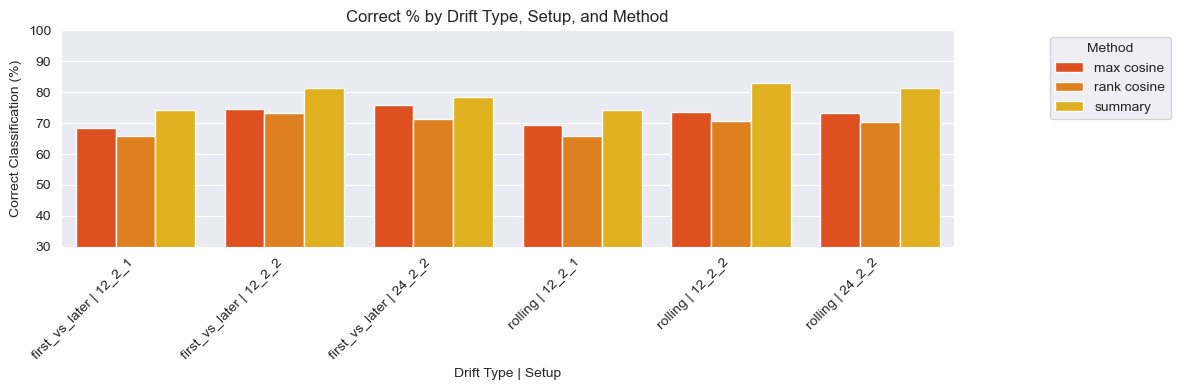

In [5]:
# sns.catplot(
#     data=results_evaluation,
#     kind="bar",
#     x="drift_type",
#     y="correct_%",
#     hue="method",
#     row="setup",
#     height=1.6,
#     aspect=1.3,
#     palette="autumn",
#     hue_order=sorted(results_evaluation['method'].unique()),
#     row_order=sorted(results_evaluation['setup'].unique()),
#     legend_out=True
# )
#
# plt.subplots_adjust(hspace=0.3)
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

# Create a combined category for drift_type and setup
results_evaluation['setup'] = results_evaluation['setup'].apply(
    lambda s: '_'.join(s.split('_')[:-1] + [str(int(int(s.split('_')[-1]) / 3600))])
)

results_evaluation['drift+setup'] = results_evaluation['drift_type'] + " | " + results_evaluation['setup']

plt.figure(figsize=(12, 4))
sns.barplot(
    data=results_evaluation,
    x='drift+setup',
    y='correct_%',
    hue='method',
    order = results_evaluation['drift+setup'].sort_values().unique(),
    palette='autumn'
)
plt.xticks(rotation=45, ha='right')
plt.ylim((30, 100))
plt.ylabel('Correct Classification (%)')
plt.xlabel('Drift Type | Setup')
plt.title('Correct % by Drift Type, Setup, and Method')
plt.legend(title='Method', bbox_to_anchor = (1.25,1))
plt.tight_layout()
plt.show()

24_12_43200 - MAX COSINE
24_12_43200 - RANK COSINE
24_12_43200 - SUMMARY
48_24_28800 - MAX COSINE
48_24_28800 - RANK COSINE
48_24_28800 - SUMMARY
48_24_7200 - MAX COSINE
48_24_7200 - RANK COSINE
48_24_7200 - SUMMARY
12_6_28800 - MAX COSINE
12_6_28800 - RANK COSINE
12_6_28800 - SUMMARY
24_12_28800 - MAX COSINE
24_12_28800 - RANK COSINE
24_12_28800 - SUMMARY
12_6_7200 - MAX COSINE
12_6_7200 - RANK COSINE
12_6_7200 - SUMMARY
48_24_43200 - MAX COSINE
48_24_43200 - RANK COSINE
48_24_43200 - SUMMARY
12_6_43200 - MAX COSINE
12_6_43200 - RANK COSINE
12_6_43200 - SUMMARY
24_12_7200 - MAX COSINE
24_12_7200 - RANK COSINE
24_12_7200 - SUMMARY


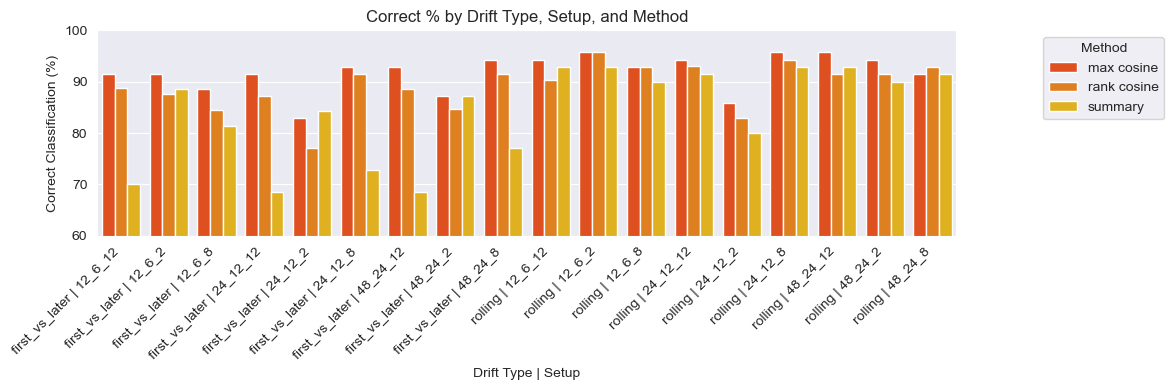

In [42]:
possible_exps = set([exp.split('__')[-2] for exp in list(results.keys())])

setup_dict = {}
for setup in possible_exps:
    exps_setup = [exp for exp in list(results.keys()) if setup in exp]
    setup_dict[setup] = exps_setup

extraction_methods = [
    ("max cosine", extract_best_clients_by_max_cosine_distance),
    ("rank cosine", extract_best_clients_by_ranked_summary_initial),
    ("summary", extract_best_clients_by_summary_metrics)
]

results_evaluation = evaluate_extraction_methods(setup_dict, results, extraction_methods)

# Create a combined category for drift_type and setup
results_evaluation['setup'] = results_evaluation['setup'].apply(
    lambda s: '_'.join(s.split('_')[:-1] + [str(int(int(s.split('_')[-1]) / 3600))])
)

results_evaluation['drift+setup'] = results_evaluation['drift_type'] + " | " + results_evaluation['setup']

plt.figure(figsize=(12, 4))
sns.barplot(
    data=results_evaluation,
    x='drift+setup',
    y='correct_%',
    hue='method',
    order = results_evaluation['drift+setup'].sort_values().unique(),
    palette='autumn'
)
plt.xticks(rotation=45, ha='right')
plt.ylim((60, 100))
plt.ylabel('Correct Classification (%)')
plt.xlabel('Drift Type | Setup')
plt.title('Correct % by Drift Type, Setup, and Method')
plt.legend(title='Method', bbox_to_anchor = (1.25,1))
plt.tight_layout()
plt.show()

In [43]:
results_evaluation

check,wrong_%,correct_%,drift_type,setup,method,drift+setup
0,8.45,91.55,first_vs_later,24_12_12,max cosine,first_vs_later | 24_12_12
1,5.71,94.29,rolling,24_12_12,max cosine,rolling | 24_12_12
2,12.86,87.14,first_vs_later,24_12_12,rank cosine,first_vs_later | 24_12_12
3,6.94,93.06,rolling,24_12_12,rank cosine,rolling | 24_12_12
4,31.43,68.57,first_vs_later,24_12_12,summary,first_vs_later | 24_12_12
5,8.57,91.43,rolling,24_12_12,summary,rolling | 24_12_12
6,5.71,94.29,first_vs_later,48_24_8,max cosine,first_vs_later | 48_24_8
7,8.57,91.43,rolling,48_24_8,max cosine,rolling | 48_24_8
8,8.57,91.43,first_vs_later,48_24_8,rank cosine,first_vs_later | 48_24_8
9,7.04,92.96,rolling,48_24_8,rank cosine,rolling | 48_24_8


In [11]:
best_cases_init = []

for experiment, content in results.items():
    exp_summary = []

    # Loop through epochs (use string keys as in your data)
    for epoch in range(0, 10):
        epoch_key = str(epoch)
        if epoch_key not in content:
            continue
        ranked_summary = content[epoch_key]['ranked']['first_4_months']['summary']
        if ranked_summary.empty:
            continue

        top_rank = ranked_summary[ranked_summary['rank_by_mean'] == 1].copy()
        top_rank['epoch'] = epoch
        exp_summary.append(top_rank)

    # If no data collected for the experiment, skip
    if not exp_summary:
        continue

    # Combine all top-rank rows across epochs
    qwe = pd.concat(exp_summary, ignore_index=True)

    # Count how often each client_id appears at rank 1 for each drift_type
    pair_counts = (
        qwe.groupby(['drift_type', 'client_id'])
           .size()
           .reset_index(name='count')
    )

    # Find top clients per drift_type (those with max count)
    max_counts = pair_counts.groupby('drift_type')['count'].transform('max')
    top_clients_per_drift = pair_counts[pair_counts['count'] == max_counts].copy()

    # Add experiment info
    top_clients_per_drift['experiment'] = experiment

    # Append
    best_cases_init.append(top_clients_per_drift[['client_id', 'drift_type', 'experiment']])

# Combine all experiments
best_cases_init_df = pd.concat(best_cases_init, ignore_index=True)

# Add derived columns
best_cases_init_df['client_drift'] = best_cases_init_df['client_id'].str.split('_').str[1]
best_cases_init_df['ground_truth'] = best_cases_init_df['experiment'].str.replace('results\\', '', regex=False).str[0]
best_cases_init_df['check'] = best_cases_init_df['client_drift'] == best_cases_init_df['ground_truth']

# View results
best_cases_init_df.head()

,client_id,drift_type,experiment,client_drift,ground_truth,check
0,District_A__proto,first_vs_later,results\A_62_LL_ML__LL_HL_ML_LH_LL_10_1_1_12_E...,A,A,True
1,District_A__proto,rolling,results\A_62_LL_ML__LL_HL_ML_LH_LL_10_1_1_12_E...,A,A,True
2,District_A__proto,first_vs_later,results\A_62_LL_ML__LL_HL_ML_LH_LL_10_1_1_12_E...,A,A,True
3,District_A__proto,rolling,results\A_62_LL_ML__LL_HL_ML_LH_LL_10_1_1_12_E...,A,A,True
4,District_A__proto,first_vs_later,results\A_62_LL_ML__LL_HL_ML_LH_LL_10_1_1_24_E...,A,A,True


In [12]:
best_cases_init_df.groupby(['drift_type', 'check']).agg({'experiment' : 'count'})

experiment
drift_type     check            
first_vs_later False          38
               True           40
rolling        False          36
               True           45

In [13]:
ct = pd.crosstab(best_cases_init_df['drift_type'], best_cases_init_df['check'], normalize='index') * 100
ct = ct.round(2)
ct.rename(columns={True: 'correct_%', False: 'wrong_%'}, inplace=True)
ct

check,wrong_%,correct_%
drift_type,,
first_vs_later,48.72,51.28
rolling,44.44,55.56


In [14]:
def get_similar_districts_from_path(path_string):
    try:
        # Split the experiment name
        parts = path_string.split('__')

        # Get target info
        header = parts[0]  # e.g., 'E_15_LL_LM'
        target_district = header.split('_')[0]  # 'E'
        target_init_state = header.split('_')[2]  # 'LL'
        target_final_state = header.split('_')[3]  # 'LM'

        # Get district state mapping
        state_mapping_str = parts[1]  # e.g., 'LM_LL_LM_LL_LL'
        district_states = state_mapping_str.split('_')

        # Districts in order
        district_names = ['A', 'B', 'C', 'D', 'E']

        if len(district_states) < 5:
            raise ValueError("Expected at least 5 states for districts A–E. Got: " + str(district_states))

        # Map district to state
        district_state_map = dict(zip(district_names, district_states[:5]))

        # Find similar districts (excluding the target itself)
        similar_initial = [d for d, s in district_state_map.items() if s == target_init_state and d != target_district]
        similar_final = [d for d, s in district_state_map.items() if s == target_final_state and d != target_district]

        return {
            "target_district": target_district,
            "target_init_state": target_init_state,
            "target_final_state": target_final_state,
            "initial_similar_districts": similar_initial,
            "final_similar_districts": similar_final
        }

    except Exception as e:
        print(f"Error parsing: {e}")
        return None


def analyze_experiment(results_df, results_id):
    try:
        info_state = get_similar_districts_from_path(results_id)
        tgt_client = results_id[0]

        top_ranked = results_df[results_df['rank'] == 1]

        summary = top_ranked.groupby(['epoch', 'label', 'client_2']).size().reset_index(name='count')
        summary['district_letter'] = summary['client_2'].str.extract(r'District_([A-Z])')

        summary['epoch'] = pd.to_numeric(summary['epoch'], errors='coerce')
        summary['label'] = pd.to_numeric(summary['label'], errors='coerce')
        summary = summary.dropna(subset=['district_letter', 'epoch', 'label'])

        # Final-only match
        summary['match_final_only'] = summary['district_letter'].isin(info_state['final_similar_districts'])

        # Warm-up rule
        def match_with_warmup(row):
            if row['label'] < 3:
                return row['district_letter'] in info_state['initial_similar_districts']
            else:
                return row['district_letter'] in info_state['final_similar_districts']

        summary['match_warmup_rule'] = summary.apply(match_with_warmup, axis=1)

        # Summarize results
        total_final = summary['match_final_only'].sum()
        total_warmup = summary['match_warmup_rule'].sum()

        matches_per_epoch = summary.groupby('epoch')[['match_final_only', 'match_warmup_rule']].sum().reset_index()
        max_final = matches_per_epoch['match_final_only'].max()
        max_warmup = matches_per_epoch['match_warmup_rule'].max()

        matches_per_epoch['experiment'] = results_id
        matches_per_epoch['max_final_matches'] = max_final
        matches_per_epoch['max_warmup_matches'] = max_warmup

        return {
            'experiment': results_id,
            'total_final_matches': total_final,
            'total_warmup_matches': total_warmup,
            'max_final_matches': max_final,
            'max_warmup_matches': max_warmup
        }

    except Exception as e:
        return {'experiment': results_id, 'error': str(e)}


def extract_exp_info(exp_id):
    try:
        parts = exp_id.split('__')
        target_header = parts[0]                     # 'E_15_LL_LM'
        mapping = parts[1]                           # 'LM_LL_LM_LL_LL'

        target_district = target_header.split('_')[0]     # 'E'
        node_id = target_header.split('_')[1]             # '15'
        init_state = target_header.split('_')[2]          # 'LL'
        final_state = target_header.split('_')[3]         # 'LM'

        aux_exp1 = exp_id.split('__')[-1]
        aux_exp2 = exp_id.split('__')[-2]

        return pd.Series([
            f"{target_district}_{node_id}",         # 'E_15'
            f"{init_state}_{final_state}",          # 'LL_LM'
            mapping[:14],                                 # 'LM_LL_LM_LL_LL'
            f"{aux_exp2}_{aux_exp1}"
        ])
    except Exception as e:
        print(f"Failed parsing exp_id: {exp_id} — {e}")
        return pd.Series([None, None, None])


def find_similar(row):
    match_cols = [col for col in ['A', 'B', 'C', 'D', 'E'] if row[col] == row['target_final_state']]
    return '_'.join(match_cols)


def compute_best_cases(df_results):

    df_results[['target_district_node', 'target_init_final_state', 'initial_state_mapping', 'exp_id']] = (
        df_results['experiment'].apply(extract_exp_info)
    )

    # Get max warmup match for each unique config
    idx = df_results.groupby(
        ['target_district_node', 'target_init_final_state', 'initial_state_mapping']
    )['total_final_matches'].idxmax()

    df_best_per_config = df_results.loc[idx].reset_index(drop=True)

    df_best_per_config['correct_epochs'] = df_best_per_config['total_final_matches'] / 24

    df_best_per_config['target_district'] = df_best_per_config['target_district_node'].str.split('_').str[0]
    df_best_per_config['target_initial_state'] = df_best_per_config['target_init_final_state'].str.split('_').str[-2]
    df_best_per_config['target_final_state'] = df_best_per_config['target_init_final_state'].str.split('_').str[-1]

    df_best_per_config[['A', 'B', 'C', 'D', 'E']] = df_best_per_config['initial_state_mapping'].str.split('_', expand = True)

    df_best_per_config.drop(columns = ['target_district_node', 'initial_state_mapping', 'target_init_final_state'], inplace = True)

    df_best_per_config['similar_districts'] = df_best_per_config.apply(find_similar, axis=1)

    # Optional: sort by warmup performance
    df_best_per_config = df_best_per_config[df_best_per_config['similar_districts'] != '']
    df_best_per_config = df_best_per_config.sort_values(by=['total_final_matches', 'max_final_matches', 'similar_districts'], ascending=[False, False, True])

    return df_best_per_config

In [15]:
import pandas as pd
import os
import glob
from collections import defaultdict

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [16]:
def compute_results(experiment_id = 'NEW_WINDOW', metrics = ['autocorr']):

    results_path = 'results'

    # Get all folder paths
    folders_with_rep = [f for f in glob.glob(os.path.join(results_path, F'*{experiment_id}*')) if os.path.isdir(f)]


    # Group by base experiment (strip off last suffix) -> for when have exp. repetition under diferent seeds
    grouped_exps = defaultdict(list)
    for path in folders_with_rep:
        folder_name = os.path.basename(path)
        if '__' in folder_name:
            base = '__'.join(folder_name.split('__')[:-1])
            grouped_exps[base].append(path)
        else:
            grouped_exps[folder_name].append(path)


    # Run analysis for each experiment folder
    epoch_results = []
    all_results = []
    for base_name, group_paths in grouped_exps.items():
        for path in group_paths:
            exp_name = os.path.basename(path)

            # Load data
            path_data = f"{results_path}/{exp_name}/Baseline_proto.parquet"
            results_proto = pd.read_parquet(path_data)
            results_tgt = results_proto[results_proto['client_1'].str.contains(f'_{exp_name[0]}_')].drop(columns=['client_1'])

            # Compute rank based on the metrics
            results_tgt['test_metric'] = results_tgt[metrics[0]]
            if len(metrics) != 1:
                for metric in metrics[1:]:
                    results_tgt['test_metric'] += results_tgt[metric]
            results_tgt['rank'] = results_tgt.groupby(['epoch', 'label'])['test_metric'].rank(method='dense', ascending=True)

            # Analyse the results over experiments
            exp_result = analyze_experiment(results_df = results_tgt, results_id = exp_name)
            all_results.append(exp_result.copy())

            # Analyse the results per epoch
            case_epochs = []
            for epoch in results_proto['epoch'].unique():
                data_epoch = results_tgt[results_tgt['epoch'] == epoch]
                result = analyze_experiment(results_df = data_epoch, results_id = exp_name)
                result['epoch'] = epoch

                case_epochs.append(result)

                result_df = pd.DataFrame(result, index = [0])
                best_epochs = compute_best_cases(result_df)
                epoch_results.append(best_epochs.copy())

    exp_df = pd.DataFrame(all_results)
    best_cases = compute_best_cases(exp_df)


    return pd.concat(epoch_results, ignore_index = True), best_cases, exp_df, epoch_results

In [18]:
data_exps = []
for metric in ['cosine', 'wavelet', 'dft', 'autocorr']:
    aux_exps = compute_results(experiment_id = 'EXPERIMENT_INCOME', metrics = [metric])
    data_exps.append(aux_exps)


A_62

cosine


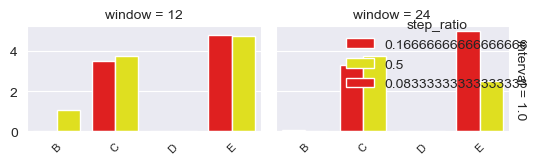


wavelet


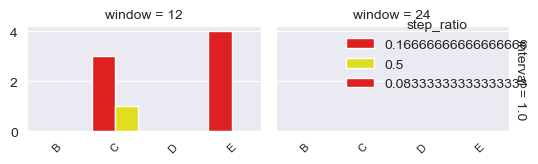


dft


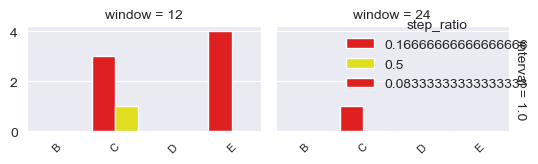


autocorr


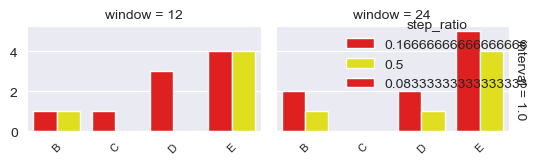


B_84

cosine


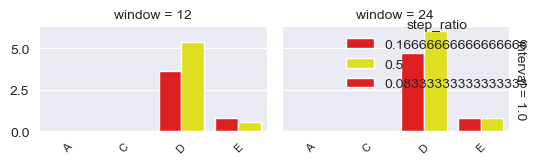


wavelet


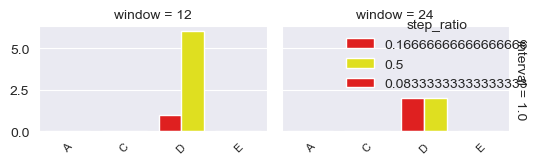


dft


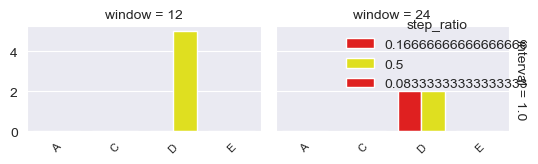


autocorr


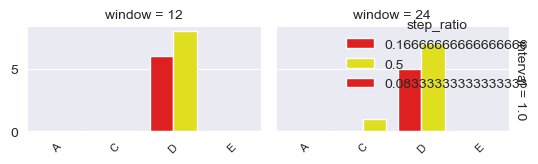


C_65

cosine


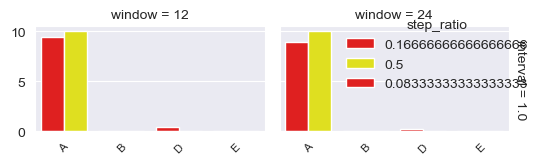


wavelet


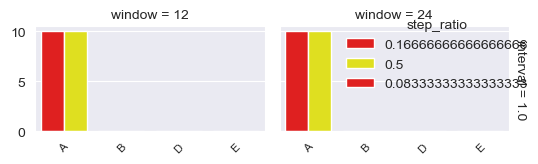


dft


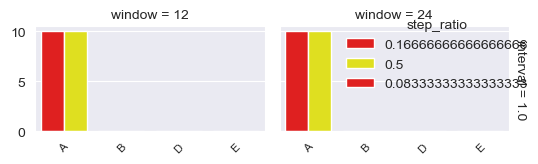


autocorr


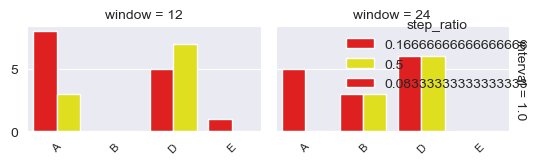


D_2

cosine


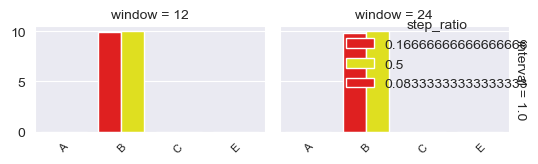


wavelet


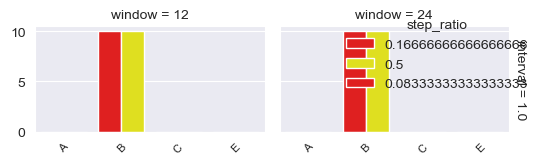


dft


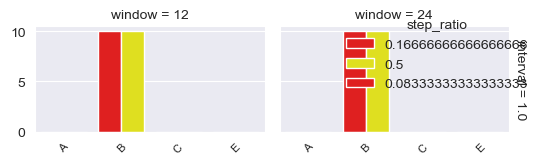


autocorr


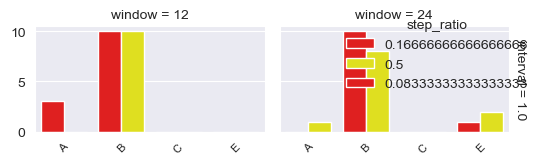


E_15

cosine


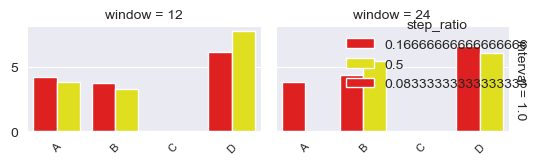


wavelet


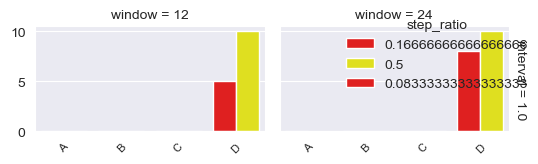


dft


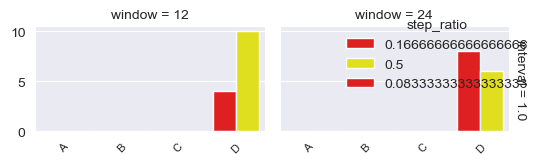


autocorr


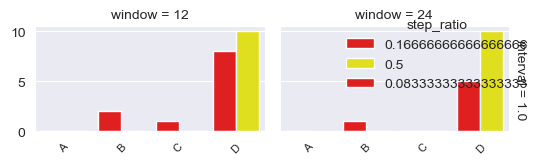

In [19]:
for district in ['A_62', 'B_84', 'C_65', 'D_2', 'E_15']:
    print(f'\n{district}')
    for i, metric in enumerate(['cosine', 'wavelet', 'dft', 'autocorr']):
        print(f'\n{metric}')

        qwe = data_exps[i][2]
        qwe = qwe[qwe['target_district_node'] == district].copy()
        qwe[['window', 'step', 'interval']] = qwe['experiment'].str.split('__').str[2].str.split('_', expand = True)
        for col in ['window', 'step', 'interval']:
            qwe[col] = qwe[col].astype(int)
        qwe['step_ratio'] = qwe['step'] / qwe['window']
        qwe['interval'] /= 3600

        qwe['target_district'] = qwe['target_district_node'].str.split('_').str[0]
        qwe['target_initial_state'] = qwe['target_init_final_state'].str.split('_').str[-2]
        qwe['target_final_state'] = qwe['target_init_final_state'].str.split('_').str[-1]

        qwe[['A', 'B', 'C', 'D', 'E']] = qwe['initial_state_mapping'].str.split('_', expand = True)

        qwe['similar_districts'] = qwe.apply(find_similar, axis=1)
        qwe['correct_epochs'] = qwe['total_final_matches'] / 24


        col_var = 'window'
        row_var = 'interval'
        hue_var = 'step_ratio'

        # Define FacetGrid with tighter spacing
        g = sns.FacetGrid(
            qwe,
            col=col_var,
            row=row_var,
            col_order=qwe[col_var].sort_values().unique(),
            row_order=qwe[row_var].sort_values().unique(),
            margin_titles=True,        # Helps use space better
            despine=False,             # Keeps axes for reference
            height=1.75,                # Smaller subplot height
            aspect=1                   # Adjust aspect ratio (width / height)
        )

        # Map barplot with narrower bars
        g.map_dataframe(
            sns.barplot,
            x='similar_districts',
            y='correct_epochs',
            order=qwe['similar_districts'].sort_values().unique(),
            hue=hue_var,
            hue_order=qwe[hue_var].sort_values().unique(),
            width=.8,
            palette='autumn'
        )

        # Reduce spacing between subplots
        g.fig.subplots_adjust(
            hspace=0.2,  # vertical space between rows
            wspace=0.05  # horizontal space between columns
        )

        # Reduce legend size and move to a compact position
        g.add_legend(title=hue_var)
        g._legend.set_bbox_to_anchor((.995, 0.625))  # move legend to side
        g._legend.set_frame_on(False)

        # Optional: Rotate x-ticks and tighten layout
        for ax in g.axes.flat:
            for label in ax.get_xticklabels():
                label.set_rotation(45)
                label.set_fontsize(8)
            ax.set_ylabel('')
            ax.set_xlabel('')


        plt.tight_layout()
        plt.show()

In [13]:
import pandas as pd
path  = 'results\A_62_LL_LH__LL_LL_LH_LM_LL_10_1_4_12_RECORDING_FIGURES_LL_LL_LH_LM_LL__12_2_14400___0'

df_lat = pd.read_parquet(path + '/Baseline_latent_space.parquet')

id_cols = ['client_id', 'label', 'epoch']
feat_cols = [col for col in df_lat.columns if 'x_' in col]
aux_agg = df_lat[id_cols + feat_cols]
aux_agg = aux_agg[~aux_agg['client_id'].str.contains('_proto')]

In [14]:
from utils.Toolbox_postprocessing import  *

In [15]:
import time


def TIME_distributions_analysis(data_distribution, target_client="District_E", epoch = 0, normalize=True):
    """
    Perform temporal distribution comparison of latent representations between a target client
    and all other clients across time (label/month), using a variety of statistical, geometric,
    and information-theoretic metrics.

    Parameters:
    -----------
    data_distribution : pd.DataFrame
        DataFrame containing latent space representations with at least:
        - 'client_id' column for client identifier.
        - 'label' column for time/month index.
        - columns prefixed with 'x_' as latent features.

    target_client : str, default="District_E"
        The client to compare against all other clients across months.

    normalize : bool, default=True
        Whether to apply min-max normalization to the resulting metric columns.

    Returns:
    --------
    df_results : pd.DataFrame
        A DataFrame with pairwise metrics between the target client and other clients for each month.
        Columns include:
            - 'month': Time label
            - 'target_client', 'other_client': Identifiers
            - 'MMD': Maximum Mean Discrepancy
            - 'Wasserstein': Wasserstein (Earth Mover's) Distance
            - 'Energy': Energy Distance
            - 'SubspaceAlignment': Subspace alignment score
            - 'DTW': Dynamic Time Warping over latent trajectories
            - 'MutualInfo': Mutual information between latent distributions
            - 'KL': Kullback-Leibler divergence
            - 'JSD': Jensen-Shannon divergence
    """
    df = data_distribution.copy()
    features = [col for col in df.columns if col.startswith("x_")]
    clients = df["client_id"].unique()
    months = sorted(df["label"].unique())

    results = []

    for month in tqdm(months):
        df_month = df[df.label == month]
        X_target = df_month[df_month.client_id == target_client][features].values


        for other_client in clients:
            if other_client == target_client:
                continue

            X_other = df_month[df_month.client_id == other_client][features].values
            if X_target.size == 0 or X_other.size == 0:
                continue

            timing = {}  # store method timing for this pair

            # 1. Distribution metrics
            t0 = time.time()
            mmd_val, w_dist, e_dist = compare_clients_distribution(X_target, X_other)
            timing["distribution"] = time.time() - t0

            # 2. Subspace alignment
            t0 = time.time()
            sa = subspace_alignment(X_target, X_other)
            timing["subspace"] = time.time() - t0

            # 3. DTW
            t0 = time.time()
            traj_target = dtw_client_trajectory(df[df.label <= month], target_client, features)
            traj_other = dtw_client_trajectory(df[df.label <= month], other_client, features)
            min_len = min(len(traj_target), len(traj_other))
            dtw_val, _ = fastdtw(traj_target[:min_len], traj_other[:min_len], dist=cosine)
            timing["dtw"] = time.time() - t0

            # 4. Mutual Information
            t0 = time.time()
            mi = compute_mi(df, target_client, other_client, month, features)
            timing["mi"] = time.time() - t0

            # 5. KL & JSD
            t0 = time.time()
            kl = compute_kl_divergence(X_target, X_other)
            jsd = compute_js_divergence(X_target, X_other)
            timing["kl_jsd"] = time.time() - t0

            results.append({
                "epoch" : epoch,
                "label": month,
                "target_client": target_client,
                "other_client": other_client,
                "MMD": mmd_val,
                "Wasserstein": w_dist,
                "Energy": e_dist,
                "SubspaceAlignment": sa,
                "DTW": dtw_val,
                "MutualInfo": mi,
                "KL": kl,
                "JSD": jsd,
                # Optional: add timing results for inspection
                "T_distribution": timing["distribution"],
                "T_subspace": timing["subspace"],
                "T_dtw": timing["dtw"],
                "T_mi": timing["mi"],
                "T_kl_jsd": timing["kl_jsd"],
            })

    df_results = pd.DataFrame(results)

    return df_results

In [16]:
results = TIME_distributions_analysis(aux_agg, target_client = 'District_A')

100%|██████████| 24/24 [02:27<00:00,  6.15s/it]


In [19]:
from utils.Toolbox_visualization import plot_proto_similar, plot_distribution_similar

path  = 'results\AA_62_LL_LH__LL_LL_LH_LM_LL_10_1_2_24_RECORDING_FIGURES_fedavg_LL_LL_LH_LM_LL__24_2_7200___0/'

df_exp_proto = pd.read_parquet(path + 'Baseline_proto.parquet')
df_exp_latent = pd.read_parquet(path + 'Baseline_distribution.parquet')

df_exp_proto['epoch'] = df_exp_proto['epoch'].astype(int)
df_exp_latent['epoch'] = df_exp_latent['epoch'].astype(int)

plot_proto_similar(df_exp_proto, results_dir = path)

plot_distribution_similar(df_exp_latent, results_dir = path)